# Stim ON vs Stim OFF — Accuracy Comparison
### Digit Span Backwards | DBS ATN Case 1 | Sessions 2 & 3

**Design:**  
Each trial from Session 2 (all 14) and Session 3 (all 14) is classified as:
- **NO-STIM** — mA < 2.0 throughout the entire trial (fixation → feedback)
- **STIM-ON** — mA ≥ 2.0 at any point during the trial

We then compare **accuracy (correct = 1, incorrect = 0)** between the two groups.

**Statistics per comparison:**
- Fisher's Exact test → p-value
- Cohen's d (pooled, binary)
- Effect size label (negligible / small / medium / large)

**Comparisons run:**
1. Session 2 only
2. Session 3 only
3. Sessions 2 + 3 combined (larger N)

Each section lists **which trial numbers** fall into NO-STIM vs STIM-ON.

## Cell 1 — Imports & Display Settings

In [26]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from scipy import stats
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams.update({
    'font.family':       'sans-serif',
    'font.size':         10,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'figure.dpi':        130,
    'savefig.dpi':       160,
    'savefig.bbox':      'tight',
    'savefig.facecolor': 'white',
})

# ── Colours ──────────────────────────────────────────────────────────────────
C_NO_STIM  = '#90A4AE'   # grey  — no stimulation
C_STIM     = '#1A56DB'   # blue  — stimulation present
C_CORRECT  = '#2E7D32'   # green
C_WRONG    = '#C62828'   # red

STIM_THRESHOLD = 2.0     # mA — threshold that defines "stim on"

print('Imports OK')

Imports OK


## Cell 2 — File Paths  ← EDIT THESE

In [27]:
JSON_PATH_S2   = Path(r"C:\Users\ASSUS\ATN\Digit Span Backwards\Data\Neural Data\DBS ATN DSB Case 1\D. Siragusa\3.5.26\Time stamp 1433\Report_Json_Session_Report_20260305T151703.json")
CSV_PATH_S2    = Path(r"C:\Users\ASSUS\ATN\Digit Span Backwards\Data\Eprime Data\Digit Span Backwards v3.2\DigitSpanBackward v3.3-6-2-Scores.csv")
EVENTS_PATH_S2 = Path(r"C:\Users\ASSUS\ATN\Digit Span Backwards\Session 2\Events.csv")
OUT_DIR_S2     = Path(r"C:\Users\ASSUS\ATN\Digit Span Backwards\Session 2")

JSON_PATH_S3   = Path(r"C:\Users\ASSUS\ATN\Digit Span Backwards\Data\Neural Data\DBS ATN DSB Case 1\D. Siragusa\3.5.26\Time stamp 1441\Report_Json_Session_Report_20260305T151912.json")
CSV_PATH_S3    = Path(r"C:\Users\ASSUS\ATN\Digit Span Backwards\Data\Eprime Data\Digit Span Backwards v3.2\DigitSpanBackward v3.3-6-3-Scores.csv")
EVENTS_PATH_S3 = Path(r"C:\Users\ASSUS\ATN\Digit Span Backwards\Session 3\Preprocessed Data\Events.csv")
OUT_DIR_S3     = Path(r"C:\Users\ASSUS\ATN\Digit Span Backwards\Session 3")

COMBINED_DIR = Path(r"C:\Users\ASSUS\ATN\Digit Span Backwards\Combined")
COMBINED_DIR.mkdir(parents=True, exist_ok=True)
OUT_DIR_S2.mkdir(parents=True, exist_ok=True)
OUT_DIR_S3.mkdir(parents=True, exist_ok=True)

print('Paths set.')

Paths set.


## Cell 3 — Data Loading & Trial Classification Functions

In [28]:
# ─────────────────────────────────────────────────────────────────────────────
# Load raw session data (LFP JSON + E-Prime CSV + Events CSV)
# ─────────────────────────────────────────────────────────────────────────────
def load_session_data(json_path, csv_path, events_path):
    with open(json_path) as f:
        report = json.load(f)
    eprime_df = pd.read_csv(csv_path,    encoding='utf-8-sig', low_memory=False)
    ev_df     = pd.read_csv(events_path, encoding='utf-8-sig', low_memory=False)

    meta = dict(
        subject = str(eprime_df['Subject'].iloc[0]),
        session = str(eprime_df['Session'].iloc[0]),
        date    = str(eprime_df['SessionDate'].iloc[0]),
    )

    # Alignment: find first 0→>0 mA transition
    stim_tick = None
    for stream in report['BrainSenseLfp']:
        prev = None
        for pkt in stream['LfpData']:
            curr = pkt['Left']['mA']
            if prev is not None and prev == 0.0 and curr > 0.0:
                stim_tick = pkt['TicksInMs']; break
            prev = curr
        if stim_tick: break
    assert stim_tick, 'No 0->+mA transition found!'

    welcome_ms    = int(eprime_df['Welcome.TargetOnsetTime'].iloc[0])
    MANUAL_OFFSET = stim_tick - welcome_ms
    def to_rel(ms): return float(ms) + MANUAL_OFFSET - stim_tick

    # Build mA trace
    ticks, mAs = [], []
    for stream in report['BrainSenseLfp']:
        for pkt in stream['LfpData']:
            ticks.append(pkt['TicksInMs'])
            mAs.append(pkt['Left']['mA'])
    ticks = np.array(ticks, dtype=float)
    mAs   = np.array(mAs,   dtype=float)
    order = np.argsort(ticks)
    ticks_rel = ticks[order] - stim_tick
    mAs       = mAs[order]

    print(f"Loaded: Subject={meta['subject']}  Session={meta['session']}  "
          f"Date={meta['date']}  mA_max={mAs.max():.2f}  N_packets={len(ticks)}")
    return report, eprime_df, ev_df, meta, to_rel, ticks_rel, mAs


# ─────────────────────────────────────────────────────────────────────────────
# Peak mA over a window (scalar — max sample in [t0, t1])
# ─────────────────────────────────────────────────────────────────────────────
def peak_mA(t0, t1, ticks_rel, mAs):
    if t0 is None or t1 is None or t1 <= t0: return 0.0
    mask = (ticks_rel >= t0) & (ticks_rel <= t1)
    if not mask.any():
        # nearest sample fallback
        idx = int(np.argmin(np.abs(ticks_rel - (t0+t1)/2)))
        return float(mAs[idx])
    return float(mAs[mask].max())


# ─────────────────────────────────────────────────────────────────────────────
# Stim fraction: proportion of [t0, t1] with mA >= threshold (duration method)
# ─────────────────────────────────────────────────────────────────────────────
def stim_frac_in_window(t0, t1, ticks_rel, mAs, threshold=2.0):
    """Returns fraction of window duration where mA >= threshold (0.0–1.0)."""
    if t0 is None or t1 is None or t1 <= t0: return 0.0
    mask = (ticks_rel >= t0) & (ticks_rel <= t1)
    t_r, t_m = ticks_rel[mask], mAs[mask]
    if len(t_r) < 2: return 0.0
    dt    = np.diff(t_r)
    mid   = (t_m[:-1] + t_m[1:]) / 2.0
    total = t_r[-1] - t_r[0]
    return float(np.sum(dt[mid >= threshold]) / total) if total > 0 else 0.0


# ─────────────────────────────────────────────────────────────────────────────
# Build trial table — ALL trials (no filter), classify stim status
# ─────────────────────────────────────────────────────────────────────────────
def build_all_trials(eprime_df, ev_df, to_rel, ticks_rel, mAs, sess_label):
    digit_rows = eprime_df['Digit'].tolist()
    trial_digit_seqs = {}
    offset = 0
    for tn in range(1, 15):
        row = ev_df[(ev_df['Event_Type']=='Main Trial Start') & (ev_df['Trial_Number']==tn)]
        if row.empty: continue
        n = int(row.iloc[0]['Num_Digits'])
        trial_digit_seqs[tn] = digit_rows[offset:offset+n]
        offset += n

    def ev_all(etype, tn):
        return ev_df[(ev_df['Event_Type']==etype) &
                     (ev_df['Trial_Number']==tn)]['Time_ms'].tolist()
    def ev_first(etype, tn):
        v = ev_all(etype, tn); return v[0] if v else None

    trials = []
    for tn in range(1, 15):
        sr = ev_df[(ev_df['Event_Type']=='Main Trial Start') & (ev_df['Trial_Number']==tn)]
        if sr.empty: continue
        r = sr.iloc[0]

        acc     = int(r['ACC'])        if pd.notna(r['ACC'])        else None
        cresp_v = r['CRESP']           if pd.notna(r['CRESP'])      else None
        resp_v  = r['RESP']            if pd.notna(r['RESP'])       else None
        nd      = int(r['Num_Digits']) if pd.notna(r['Num_Digits']) else None
        if None in (acc, cresp_v, resp_v, nd): continue

        cresp_s   = str(int(cresp_v)).zfill(nd)
        resp_s    = str(int(resp_v)).zfill(nd)
        presented = cresp_s[::-1]

        # Trial boundaries (relative ms)
        t_start_ms = ev_first('Main Trial Start', tn)
        t_end_ms   = ev_first('Main Trial End',   tn)
        t_start    = to_rel(t_start_ms) if t_start_ms else None
        t_end      = to_rel(t_end_ms)   if t_end_ms   else None

        fix_starts  = [to_rel(ms) for ms in ev_all('Fixation Start', tn)]
        stim_starts = [to_rel(ms) for ms in ev_all('Stimulus Start', tn)]
        stim_ends   = [to_rel(ms) for ms in ev_all('Stimulus End',   tn)]
        cs_ms = ev_first('Choice Start',   tn); cs = to_rel(cs_ms) if cs_ms else None
        ce_ms = ev_first('Choice End',     tn); ce = to_rel(ce_ms) if ce_ms else None
        fs_ms = ev_first('Feedback Start', tn); fs = to_rel(fs_ms) if fs_ms else None
        fe_ms = ev_first('Feedback End',   tn); fe = to_rel(fe_ms) if fe_ms else None

        # ── Whole-trial stim classification (≥50% duration >= threshold) ──────
        # Use first fixation start to feedback end (full cognitive span)
        trial_lo = fix_starts[0] if fix_starts else t_start
        trial_hi = fe if fe else t_end
        whole_peak = peak_mA(trial_lo, trial_hi, ticks_rel, mAs)
        whole_frac = stim_frac_in_window(trial_lo, trial_hi, ticks_rel, mAs, STIM_THRESHOLD)

        stim_present = (whole_frac >= 0.3)  # True = ≥30% of trial window has mA >= threshold

        # Per-window peak mA (for detailed reporting)
        fix_peak  = max((peak_mA(fs, ss, ticks_rel, mAs)
                         for fs, ss in zip(fix_starts, stim_starts)), default=0.0)
        stim_peak = max((peak_mA(ss, se, ticks_rel, mAs)
                         for ss, se in zip(stim_starts, stim_ends)), default=0.0)
        ch_peak   = peak_mA(cs, ce, ticks_rel, mAs)
        fb_peak   = peak_mA(fs, fe, ticks_rel, mAs)

        trials.append(dict(
            session       = sess_label,
            trial_num     = tn,
            digits        = nd,
            acc           = acc,
            presented     = presented,
            cresp         = cresp_s,
            resp          = resp_s,
            digit_seq     = trial_digit_seqs.get(tn, []),
            stim_present  = stim_present,       # bool: any stim in trial
            whole_peak_mA = round(whole_peak, 3),
            fix_peak_mA   = round(fix_peak,  3),
            stim_peak_mA  = round(stim_peak, 3),
            ch_peak_mA    = round(ch_peak,   3),
            fb_peak_mA    = round(fb_peak,   3),
        ))

    return trials


print('Functions defined.')

Functions defined.


## Cell 4 — Statistical Helper Functions

In [29]:
def cohens_d(a, b):
    a, b = np.asarray(a, float), np.asarray(b, float)
    if len(a) < 2 or len(b) < 2: return np.nan
    pooled = np.sqrt(((len(a)-1)*np.var(a, ddof=1) +
                      (len(b)-1)*np.var(b, ddof=1)) / (len(a)+len(b)-2))
    return float((np.mean(a) - np.mean(b)) / pooled) if pooled > 0 else np.nan

def effect_label(d):
    if np.isnan(d): return 'N/A'
    v = abs(d)
    if v >= 0.8: return 'large'
    if v >= 0.5: return 'medium'
    if v >= 0.2: return 'small'
    return 'negligible'

def sig_stars(p):
    if np.isnan(p): return ''
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return 'ns'

def run_comparison(no_stim_trials, stim_trials, label):
    acc_no  = np.array([t['acc'] for t in no_stim_trials], dtype=float)
    acc_on  = np.array([t['acc'] for t in stim_trials],    dtype=float)

    n_no, n_corr_no = len(acc_no), int(acc_no.sum())
    n_on, n_corr_on = len(acc_on), int(acc_on.sum())

    pct_no = acc_no.mean()*100 if n_no > 0 else np.nan
    pct_on = acc_on.mean()*100 if n_on > 0 else np.nan

    # Fisher's exact (2x2: correct/wrong x no-stim/stim)
    if n_no > 0 and n_on > 0:
        _, p = stats.fisher_exact([
            [n_corr_no,  n_no - n_corr_no],
            [n_corr_on,  n_on - n_corr_on]
        ])
        p = float(p)
    else:
        p = np.nan

    d = cohens_d(acc_no, acc_on)

    return dict(
        label        = label,
        n_no_stim    = n_no,
        correct_no   = n_corr_no,
        pct_no       = pct_no,
        n_stim       = n_on,
        correct_on   = n_corr_on,
        pct_on       = pct_on,
        p_value      = p,
        stars        = sig_stars(p),
        cohens_d     = d,
        effect_size  = effect_label(d),
    )

print('Stats helpers defined.')

Stats helpers defined.


## Cell 5 — Load Sessions & Classify Trials

In [30]:
# ── Session 2 ────────────────────────────────────────────────────────────────
_, ep_s2, ev_s2, meta_s2, to_rel_s2, tr_s2, mA_s2 = \
    load_session_data(JSON_PATH_S2, CSV_PATH_S2, EVENTS_PATH_S2)
all_s2 = build_all_trials(ep_s2, ev_s2, to_rel_s2, tr_s2, mA_s2, 'Session 2')

print()

# ── Session 3 ────────────────────────────────────────────────────────────────
_, ep_s3, ev_s3, meta_s3, to_rel_s3, tr_s3, mA_s3 = \
    load_session_data(JSON_PATH_S3, CSV_PATH_S3, EVENTS_PATH_S3)
all_s3 = build_all_trials(ep_s3, ev_s3, to_rel_s3, tr_s3, mA_s3, 'Session 3')

# ── Combined ─────────────────────────────────────────────────────────────────
all_combined = all_s2 + all_s3

print(f'\nTotal trials — S2: {len(all_s2)}, S3: {len(all_s3)}, Combined: {len(all_combined)}')

Loaded: Subject=6  Session=2  Date=03-05-2026  mA_max=4.60  N_packets=386

Loaded: Subject=6  Session=3  Date=03-05-2026  mA_max=4.70  N_packets=378

Total trials — S2: 14, S3: 14, Combined: 28


## Cell 6 — Trial Inventory: Which Trials Have Stim ON vs NO-STIM

In [31]:
def print_trial_inventory(trials, sess_label):
    no_stim = [t for t in trials if not t['stim_present']]
    stim_on = [t for t in trials if     t['stim_present']]

    print(f'{"="*70}')
    print(f'  {sess_label}  —  Stim threshold: >= {STIM_THRESHOLD} mA anywhere in trial')
    print(f'{"="*70}')

    print(f'\n  NO-STIM trials (peak mA < {STIM_THRESHOLD} throughout): '
          f'n = {len(no_stim)}')
    if no_stim:
        header = f'  {"Trial":>6}  {"Digits":>6}  {"Acc":>4}  {"Presented":>10}  '\
                 f'{"Response":>10}  {"PeakMa":>8}  {"Fix_mA":>7}  {"Stim_mA":>8}  '\
                 f'{"Choice_mA":>10}  {"Fb_mA":>7}'
        print(header)
        print('  ' + '-'*100)
        for t in no_stim:
            acc_str = 'CORRECT' if t['acc']==1 else 'WRONG'
            print(f'  T{t["trial_num"]:>5}  {t["digits"]:>6}  {acc_str:>7}  '
                  f'{t["presented"]:>10}  {t["resp"]:>10}  '
                  f'{t["whole_peak_mA"]:>8.3f}  {t["fix_peak_mA"]:>7.3f}  '
                  f'{t["stim_peak_mA"]:>8.3f}  {t["ch_peak_mA"]:>10.3f}  '
                  f'{t["fb_peak_mA"]:>7.3f}')

    print(f'\n  STIM-ON trials (peak mA >= {STIM_THRESHOLD} somewhere): '
          f'n = {len(stim_on)}')
    if stim_on:
        header = f'  {"Trial":>6}  {"Digits":>6}  {"Acc":>4}  {"Presented":>10}  '\
                 f'{"Response":>10}  {"PeakMa":>8}  {"Fix_mA":>7}  {"Stim_mA":>8}  '\
                 f'{"Choice_mA":>10}  {"Fb_mA":>7}'
        print(header)
        print('  ' + '-'*100)
        for t in stim_on:
            acc_str = 'CORRECT' if t['acc']==1 else 'WRONG'
            print(f'  T{t["trial_num"]:>5}  {t["digits"]:>6}  {acc_str:>7}  '
                  f'{t["presented"]:>10}  {t["resp"]:>10}  '
                  f'{t["whole_peak_mA"]:>8.3f}  {t["fix_peak_mA"]:>7.3f}  '
                  f'{t["stim_peak_mA"]:>8.3f}  {t["ch_peak_mA"]:>10.3f}  '
                  f'{t["fb_peak_mA"]:>7.3f}')
    print()


print_trial_inventory(all_s2, 'Session 2')
print_trial_inventory(all_s3, 'Session 3')
print_trial_inventory(all_combined, 'Combined (S2 + S3)')

  Session 2  —  Stim threshold: >= 2.0 mA anywhere in trial

  NO-STIM trials (peak mA < 2.0 throughout): n = 6
   Trial  Digits   Acc   Presented    Response    PeakMa   Fix_mA   Stim_mA   Choice_mA    Fb_mA
  ----------------------------------------------------------------------------------------------------
  T    1       2  CORRECT          43          34     1.100    1.100     1.000       0.900    0.900
  T    2       2  CORRECT          52          25     1.200    1.000     1.100       1.100    1.200
  T    3       3  CORRECT         141         141     2.000    2.000     2.000       2.000    0.100
  T    4       3  CORRECT         235         532     0.100    0.100     0.100       0.100    0.100
  T    5       4  CORRECT        2345        5432     1.100    0.100     0.200       1.100    1.100
  T    6       4    WRONG        1245        5432     1.000    1.000     1.900       1.900    1.900

  STIM-ON trials (peak mA >= 2.0 somewhere): n = 8
   Trial  Digits   Acc   Presented  

## Cell 7 — Statistical Comparison: NO-STIM vs STIM-ON Accuracy

In [32]:
def print_stats(result):
    p  = result['p_value']
    d  = result['cohens_d']
    p_s = f'{p:.4f}' if not np.isnan(p) else 'N/A'
    d_s = f'{d:+.3f}' if not np.isnan(d) else 'N/A'
    print(f'  {"Group":<15}  {"N":>4}  {"Correct":>8}  {"Acc %":>7}')
    print(f'  {"-"*42}')
    print(f'  {"NO-STIM":<15}  {result["n_no_stim"]:>4}  '
          f'{result["correct_no"]:>8}  '
          f'{result["pct_no"]:>6.1f}%')
    print(f'  {"STIM-ON":<15}  {result["n_stim"]:>4}  '
          f'{result["correct_on"]:>8}  '
          f'{result["pct_on"]:>6.1f}%')
    print(f'  {"-"*42}')
    print(f'  Fisher p-value : {p_s}  {result["stars"]}')
    print(f'  Cohen\'s d      : {d_s}')
    print(f'  Effect size    : {result["effect_size"]}')
    print()


results = {}

for label, trials in [
    ('Session 2',          all_s2),
    ('Session 3',          all_s3),
    ('Combined (S2 + S3)', all_combined),
]:
    no_stim = [t for t in trials if not t['stim_present']]
    stim_on = [t for t in trials if     t['stim_present']]

    res = run_comparison(no_stim, stim_on, label)
    results[label] = res

    nos_trials = ', '.join(f'T{t["trial_num"]}' for t in no_stim)
    son_trials = ', '.join(f'T{t["trial_num"]}' for t in stim_on)

    print(f'{"="*60}')
    print(f'  {label}')
    print(f'{"="*60}')
    print(f'  NO-STIM trials : {nos_trials if nos_trials else "none"}')
    print(f'  STIM-ON trials : {son_trials if son_trials else "none"}')
    print()
    print_stats(res)

  Session 2
  NO-STIM trials : T1, T2, T3, T4, T5, T6
  STIM-ON trials : T7, T8, T9, T10, T11, T12, T13, T14

  Group               N   Correct    Acc %
  ------------------------------------------
  NO-STIM             6         5    83.3%
  STIM-ON             8         1    12.5%
  ------------------------------------------
  Fisher p-value : 0.0256  *
  Cohen's d      : +1.877
  Effect size    : large

  Session 3
  NO-STIM trials : T1, T2, T5, T6, T8, T9, T11, T12, T13, T14
  STIM-ON trials : T3, T4, T7, T10

  Group               N   Correct    Acc %
  ------------------------------------------
  NO-STIM            10         6    60.0%
  STIM-ON             4         2    50.0%
  ------------------------------------------
  Fisher p-value : 1.0000  ns
  Cohen's d      : +0.188
  Effect size    : negligible

  Combined (S2 + S3)
  NO-STIM trials : T1, T2, T3, T4, T5, T6, T1, T2, T5, T6, T8, T9, T11, T12, T13, T14
  STIM-ON trials : T7, T8, T9, T10, T11, T12, T13, T14, T3, T4, T7,

## Cell 8 — Main Comparison Plot: Accuracy by Stim Group

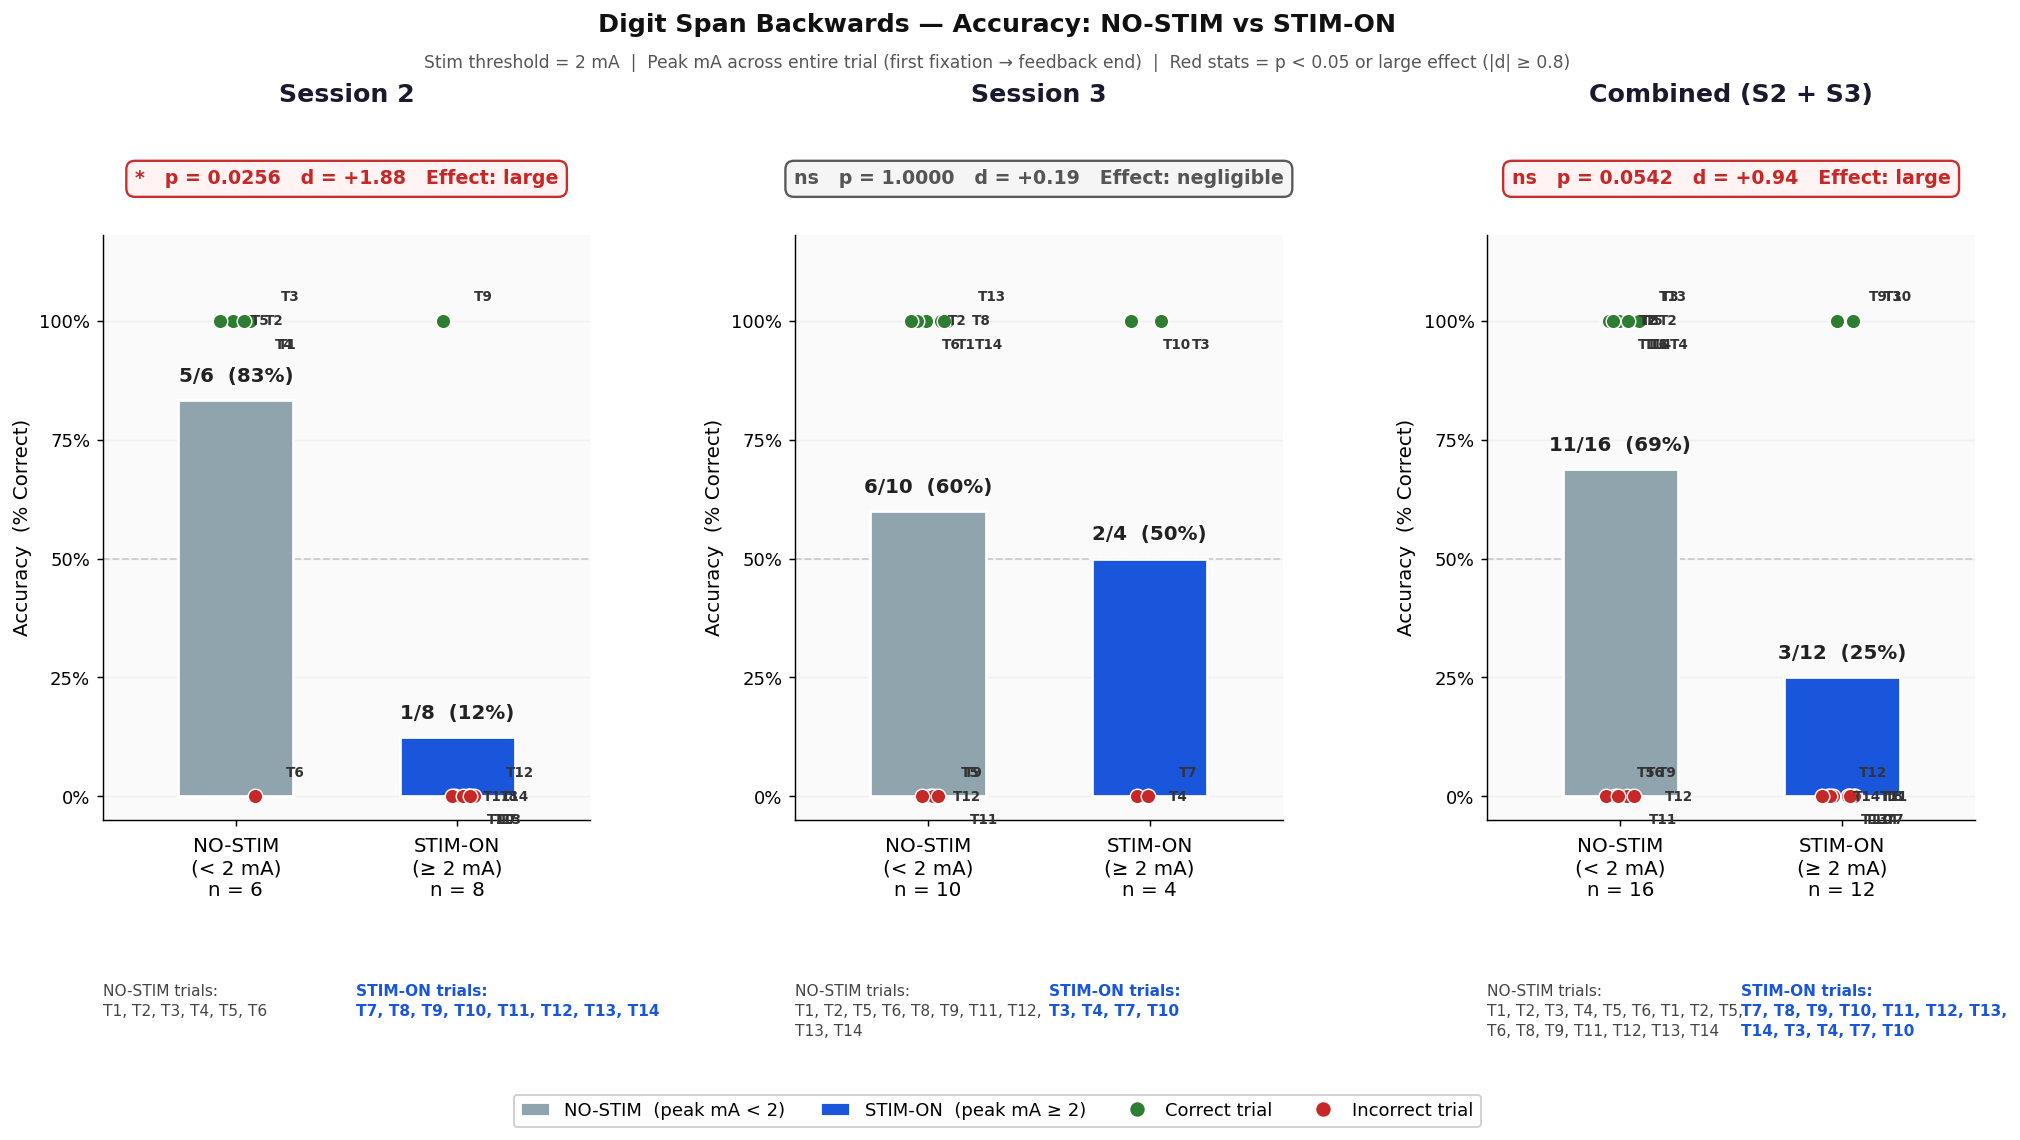

Saved -> C:\Users\ASSUS\ATN\Digit Span Backwards\Combined\accuracy_no_stim_vs_stim_on.png


In [33]:
from textwrap import wrap


def plot_accuracy_comparison(results_dict, all_s2, all_s3, all_combined, save_dir):
    sessions = [
        ('Session 2',          all_s2,       results_dict['Session 2']),
        ('Session 3',          all_s3,       results_dict['Session 3']),
        ('Combined (S2 + S3)', all_combined, results_dict['Combined (S2 + S3)']),
    ]

    fig, axes = plt.subplots(1, 3, figsize=(16, 9), facecolor='white')
    fig.subplots_adjust(wspace=0.42, top=0.78, bottom=0.28, left=0.07, right=0.97)

    rng = np.random.default_rng(42)

    for ax, (sess_label, trials, res) in zip(axes, sessions):
        no_stim = [t for t in trials if not t['stim_present']]
        stim_on = [t for t in trials if     t['stim_present']]
        acc_no  = np.array([t['acc'] for t in no_stim], dtype=float)
        acc_on  = np.array([t['acc'] for t in stim_on], dtype=float)

        pct_no = acc_no.mean()*100 if len(acc_no) > 0 else 0.0
        pct_on = acc_on.mean()*100 if len(acc_on) > 0 else 0.0

        # ── Bars
        ax.bar([0], [pct_no], width=0.52, color=C_NO_STIM, zorder=3, edgecolor='white', linewidth=1.5)
        ax.bar([1], [pct_on], width=0.52, color=C_STIM,    zorder=3, edgecolor='white', linewidth=1.5)

        # ── Count/% labels above bars
        for xi, pct, n_corr, n_tot in [
            (0, pct_no, res['correct_no'], res['n_no_stim']),
            (1, pct_on, res['correct_on'], res['n_stim']),
        ]:
            ax.text(xi, max(pct, 2) + 3,
                    f'{n_corr}/{n_tot}  ({pct:.0f}%)',
                    ha='center', va='bottom', fontsize=11, fontweight='bold', color='#222', zorder=8)

        # ── Individual trial dots (x-jitter only, y fixed at 0 or 100)
        for xi, accs, tlist in [(0, acc_no, no_stim), (1, acc_on, stim_on)]:
            if len(accs) == 0:
                continue
            jitter_x = rng.uniform(-0.09, 0.09, size=len(accs))
            for k, (t, jx) in enumerate(zip(tlist, jitter_x)):
                y_dot   = float(t['acc']) * 100
                dot_col = C_CORRECT if t['acc'] == 1 else C_WRONG
                ax.scatter(xi + jx, y_dot, c=dot_col, s=65, zorder=7, edgecolors='white', linewidths=0.8)
                stagger = (k % 3) * 5 - 5
                ax.text(xi + jx + 0.14, y_dot + stagger,
                        f'T{t["trial_num"]}',
                        fontsize=7.5, ha='left', va='center', color='#333', zorder=9, fontweight='bold')

        # ── Axes
        ax.set_xlim(-0.60, 1.60)
        ax.set_ylim(-5, 118)
        ax.set_xticks([0, 1])
        ax.set_xticklabels(
            [f'NO-STIM\n(< {STIM_THRESHOLD:.0f} mA)\nn = {res["n_no_stim"]}',
             f'STIM-ON\n(\u2265 {STIM_THRESHOLD:.0f} mA)\nn = {res["n_stim"]}'],
            fontsize=11)
        ax.tick_params(axis='x', pad=6)
        ax.set_yticks([0, 25, 50, 75, 100])
        ax.set_yticklabels(['0%', '25%', '50%', '75%', '100%'], fontsize=10)
        ax.set_ylabel('Accuracy  (% Correct)', fontsize=11)
        ax.axhline(50, color='#ccc', lw=1.0, ls='--', zorder=1)
        ax.yaxis.grid(True, color='#f0f0f0', zorder=0)
        ax.set_axisbelow(True)
        ax.set_facecolor('#FAFAFA')
        ax.text(0.5, 1.22, sess_label,
        transform=ax.transAxes,
        ha='center', va='bottom',
        fontsize=14,
        fontweight='bold',
        color='#1A1A2E')

        # ── Stats box placed ABOVE title (in axes coords, y > 1)
        p_v  = res['p_value']
        d_v  = res['cohens_d']
        eff  = effect_label(d_v)
        sig  = sig_stars(p_v)
        p_str  = f'p = {p_v:.4f}' if not np.isnan(p_v) else 'p = N/A'
        d_str  = f'd = {d_v:+.2f}' if not np.isnan(d_v) else 'd = N/A'

        is_notable = ((not np.isnan(p_v) and p_v < 0.05) or
                      (not np.isnan(d_v) and abs(d_v) >= 0.8))
        stat_col  = '#C62828' if is_notable else '#555555'
        box_col   = '#FFF3F3' if is_notable else '#F5F5F5'

        ax.text(0.5, 1.08,
                f'{sig}   {p_str}   {d_str}   Effect: {eff}',
                transform=ax.transAxes,
                ha='center', va='bottom', fontsize=10.5, fontweight='bold',
                color=stat_col,
                bbox=dict(boxstyle='round,pad=0.45', fc=box_col, ec=stat_col, lw=1.3, alpha=0.97),
                zorder=10)

        # ── Trial lists below x-axis ticks
        def wrap_trials(trials, width=35):
            return "\n".join(wrap(", ".join(trials), width=width)) if trials else "—"

        nos_list = wrap_trials([f'T{t["trial_num"]}' for t in no_stim])
        son_list = wrap_trials([f'T{t["trial_num"]}' for t in stim_on])
        ax.text(0.0, -0.28, f'NO-STIM trials:\n{nos_list}',
        transform=ax.transAxes,
        ha='left', va='top',
        fontsize=8.5,
        color='#444',
        linespacing=1.4)

        ax.text(0.52, -0.28, f'STIM-ON trials:\n{son_list}',
                transform=ax.transAxes,
                ha='left', va='top',
                fontsize=8.5,
                color='#1A56DB',
                linespacing=1.4,
                fontweight='bold')

    # ── Legend
    legend_handles = [
        mpatches.Patch(facecolor=C_NO_STIM, edgecolor='white', label=f'NO-STIM  (peak mA < {STIM_THRESHOLD:.0f})'),
        mpatches.Patch(facecolor=C_STIM,    edgecolor='white', label=f'STIM-ON  (peak mA \u2265 {STIM_THRESHOLD:.0f})'),
        plt.Line2D([0],[0], marker='o', color='w', markerfacecolor=C_CORRECT, markersize=9, label='Correct trial'),
        plt.Line2D([0],[0], marker='o', color='w', markerfacecolor=C_WRONG,   markersize=9, label='Incorrect trial'),
    ]
    fig.legend(handles=legend_handles, loc='lower center', ncol=4,
               fontsize=10, framealpha=0.97, facecolor='white', edgecolor='#ccc',
               bbox_to_anchor=(0.5, 0.01), columnspacing=2.0, handlelength=1.6)

    # ── Suptitle
    fig.text(0.5, 0.97,
             'Digit Span Backwards \u2014 Accuracy: NO-STIM vs STIM-ON',
             ha='center', va='top', fontsize=14, fontweight='bold', color='#111')
    fig.text(0.5, 0.935,
             f'Stim threshold = {STIM_THRESHOLD:.0f} mA  |  Peak mA across entire trial '
             '(first fixation \u2192 feedback end)  |  '
             'Red stats = p < 0.05 or large effect (|d| \u2265 0.8)',
             ha='center', va='top', fontsize=9.5, color='#555')

    fname = save_dir / 'accuracy_no_stim_vs_stim_on.png'
    fig.savefig(fname, bbox_inches='tight', dpi=160, facecolor='white')
    plt.show()
    plt.close(fig)
    print(f'Saved -> {fname}')


plot_accuracy_comparison(results, all_s2, all_s3, all_combined, COMBINED_DIR)


## Cell 9 — Detailed Per-Window mA Breakdown Table

In [34]:
def make_detail_df(trials):
    rows = []
    for t in trials:
        rows.append(dict(
            Session       = t['session'],
            Trial         = f'T{t["trial_num"]}',
            Digits        = t['digits'],
            Presented     = t['presented'],
            Response      = t['resp'],
            Correct       = 'YES' if t['acc']==1 else 'NO',
            Stim_Group    = 'STIM-ON' if t['stim_present'] else 'NO-STIM',
            Peak_mA_whole = t['whole_peak_mA'],
            Peak_mA_fix   = t['fix_peak_mA'],
            Peak_mA_stim  = t['stim_peak_mA'],
            Peak_mA_choice= t['ch_peak_mA'],
            Peak_mA_fb    = t['fb_peak_mA'],
        ))
    return pd.DataFrame(rows)

df_detail = pd.concat([
    make_detail_df(all_s2),
    make_detail_df(all_s3),
], ignore_index=True)

# Style: highlight stim group
def colour_group(val):
    if val == 'STIM-ON': return 'background-color: #BBDEFB; font-weight: bold'
    if val == 'NO-STIM':  return 'background-color: #EEEEEE; font-weight: bold'
    return ''

def colour_correct(val):
    if val == 'YES': return 'color: #2E7D32; font-weight: bold'
    if val == 'NO':  return 'color: #C62828; font-weight: bold'
    return ''

display(df_detail.style
    .map(colour_group,   subset=['Stim_Group'])
    .map(colour_correct, subset=['Correct'])
    .set_caption('All trials — per-window peak mA  |  Stim threshold = 2.0 mA')
    .format({'Peak_mA_whole':'.3f','Peak_mA_fix':'.3f',
             'Peak_mA_stim':'.3f','Peak_mA_choice':'.3f','Peak_mA_fb':'.3f'})
)

,Session,Trial,Digits,Presented,Response,Correct,Stim_Group,Peak_mA_whole,Peak_mA_fix,Peak_mA_stim,Peak_mA_choice,Peak_mA_fb
0,Session 2,T1,2,43,34,YES,NO-STIM,.3f,.3f,.3f,.3f,.3f
1,Session 2,T2,2,52,25,YES,NO-STIM,.3f,.3f,.3f,.3f,.3f
2,Session 2,T3,3,141,141,YES,NO-STIM,.3f,.3f,.3f,.3f,.3f
3,Session 2,T4,3,235,532,YES,NO-STIM,.3f,.3f,.3f,.3f,.3f
4,Session 2,T5,4,2345,5432,YES,NO-STIM,.3f,.3f,.3f,.3f,.3f
5,Session 2,T6,4,1245,5432,NO,NO-STIM,.3f,.3f,.3f,.3f,.3f
6,Session 2,T7,4,3124,4231,NO,STIM-ON,.3f,.3f,.3f,.3f,.3f
7,Session 2,T8,4,1354,5341,NO,STIM-ON,.3f,.3f,.3f,.3f,.3f
8,Session 2,T9,4,2315,5132,YES,STIM-ON,.3f,.3f,.3f,.3f,.3f
9,Session 2,T10,4,1432,2314,NO,STIM-ON,.3f,.3f,.3f,.3f,.3f


## Cell 10 — Summary Statistics Table & CSV Export

In [35]:
summary_rows = []
for label, trials in [('Session 2', all_s2), ('Session 3', all_s3),
                       ('Combined (S2 + S3)', all_combined)]:
    no_stim = [t for t in trials if not t['stim_present']]
    stim_on = [t for t in trials if     t['stim_present']]
    res = results[label]

    nos_tlist = ', '.join(f'T{t["trial_num"]}' for t in no_stim) or 'none'
    son_tlist = ', '.join(f'T{t["trial_num"]}' for t in stim_on) or 'none'

    p  = res['p_value']
    d  = res['cohens_d']
    summary_rows.append(dict(
        Session           = label,
        NO_STIM_trials    = nos_tlist,
        STIM_ON_trials    = son_tlist,
        N_NO_STIM         = res['n_no_stim'],
        Correct_NO_STIM   = f"{res['correct_no']}/{res['n_no_stim']} ({res['pct_no']:.0f}%)",
        N_STIM_ON         = res['n_stim'],
        Correct_STIM_ON   = f"{res['correct_on']}/{res['n_stim']} ({res['pct_on']:.0f}%)",
        p_value_Fisher    = f'{p:.4f}' if not np.isnan(p) else 'N/A',
        Significance      = res['stars'],
        Cohens_d          = f'{d:+.3f}' if not np.isnan(d) else 'N/A',
        Effect_Size       = res['effect_size'],
    ))

summary_df = pd.DataFrame(summary_rows)
display(summary_df)

out_csv = COMBINED_DIR / 'stim_on_vs_no_stim_accuracy_stats.csv'
summary_df.to_csv(out_csv, index=False)
detail_csv = COMBINED_DIR / 'all_trials_stim_detail.csv'
df_detail.to_csv(detail_csv, index=False)
print(f'Saved -> {out_csv}')
print(f'Saved -> {detail_csv}')

,Session,NO_STIM_trials,STIM_ON_trials,N_NO_STIM,Correct_NO_STIM,N_STIM_ON,Correct_STIM_ON,p_value_Fisher,Significance,Cohens_d,Effect_Size
0,Session 2,"T1, T2, T3, T4, T5, T6","T7, T8, T9, T10, T11, T12, T13, T14",6,5/6 (83%),8,1/8 (12%),0.0256,*,+1.877,large
1,Session 3,"T1, T2, T5, T6, T8, T9, T11, T12, T13, T14","T3, T4, T7, T10",10,6/10 (60%),4,2/4 (50%),1.0000,ns,+0.188,negligible
2,Combined (S2 + S3),"T1, T2, T3, T4, T5, T6, T1, T2, T5, T6, T8, T9...","T7, T8, T9, T10, T11, T12, T13, T14, T3, T4, T...",16,11/16 (69%),12,3/12 (25%),0.0542,ns,+0.935,large


Saved -> C:\Users\ASSUS\ATN\Digit Span Backwards\Combined\stim_on_vs_no_stim_accuracy_stats.csv
Saved -> C:\Users\ASSUS\ATN\Digit Span Backwards\Combined\all_trials_stim_detail.csv
